# Sales Prediction using Random Forest (Next 3 Months)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

## Sample Data (Based on your image)

In [4]:
data = {
    'SALES_DATE': ['2022-04-04','2022-04-05','2022-04-06','2022-04-07','2022-04-08'],
    'TOTAL_INVOICE': [406,4467,3791,3813,6053],
    'TOTAL_CBS': [41350,520281,425154,388320,574013],
    'TOTAL_BTLS': [4901,95769,73097,81051,139159],
    'TOTAL_QTY_IN_BTLS': [2311961,26844096,20959832,20301528,27820882],
    'TOTAL_CB_PER': [41452.44,522146.40,426678.76,390038.14,576810.07],
    'SALES_VALUE': [1.26e8,1.63e9,1.36e9,1.24e9,1.85e9],
    'SALES_VOLUME': [351002.89,4419829.32,3616022.37,3307042.60,4882969.31]
}

df = pd.DataFrame(data)
df['SALES_DATE'] = pd.to_datetime(df['SALES_DATE'])
df = df.sort_values('SALES_DATE')
df.set_index('SALES_DATE', inplace=True)
df.to_csv('sales_data.csv')
df.head()


,TOTAL_INVOICE,TOTAL_CBS,TOTAL_BTLS,TOTAL_QTY_IN_BTLS,TOTAL_CB_PER,SALES_VALUE,SALES_VOLUME
SALES_DATE,,,,,,,
2022-04-04,406,41350,4901,2311961,41452.44,1.260000e+08,351002.89
2022-04-05,4467,520281,95769,26844096,522146.40,1.630000e+09,4419829.32
2022-04-06,3791,425154,73097,20959832,426678.76,1.360000e+09,3616022.37
2022-04-07,3813,388320,81051,20301528,390038.14,1.240000e+09,3307042.60
2022-04-08,6053,574013,139159,27820882,576810.07,1.850000e+09,4882969.31


## Feature Engineering

In [26]:
target = 'SALES_VALUE'

df['day'] = df.index.day
df['month'] = df.index.month
df['week'] = df.index.isocalendar().week.astype(int)
df['day_of_week'] = df.index.dayofweek

df['lag_1'] = df[target].shift(1)
df['lag_2'] = df[target].shift(2)

df.dropna(inplace=True)
df

,TOTAL_INVOICE,TOTAL_CBS,TOTAL_BTLS,TOTAL_QTY_IN_BTLS,TOTAL_CB_PER,SALES_VALUE,SALES_VOLUME,day,month,week,day_of_week,lag_1,lag_2
SALES_DATE,,,,,,,,,,,,,
2022-04-06,3791,425154,73097,20959832,426678.76,1.360000e+09,3616022.37,6,4,14,2,1.630000e+09,1.260000e+08
2022-04-07,3813,388320,81051,20301528,390038.14,1.240000e+09,3307042.60,7,4,14,3,1.360000e+09,1.630000e+09
2022-04-08,6053,574013,139159,27820882,576810.07,1.850000e+09,4882969.31,8,4,14,4,1.240000e+09,1.360000e+09


## Train Model

In [27]:
X = df.drop(columns=[target])
y = df[target]

# 80% train, 20% test (time order maintain)
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_train)
print('MAE:', mean_absolute_error(y_train, pred))

MAE: 28800000.0


In [28]:
feature_cols = X.columns
feature_cols

Index(['TOTAL_INVOICE', 'TOTAL_CBS', 'TOTAL_BTLS', 'TOTAL_QTY_IN_BTLS',
       'TOTAL_CB_PER', 'SALES_VOLUME', 'day', 'month', 'week', 'day_of_week',
       'lag_1', 'lag_2'],
      dtype='object')

## Future Prediction (Next 90 Days)

In [29]:
future_days = 90

# next day se start karo (important)
future_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1), periods=future_days)

future_df = pd.DataFrame(index=future_dates)

# date features
future_df['day'] = future_df.index.day
future_df['month'] = future_df.index.month
future_df['week'] = future_df.index.isocalendar().week.astype(int)
future_df['day_of_week'] = future_df.index.dayofweek

# 👉 IMPORTANT: training ke columns save hone chahiye
feature_cols = X.columns

last_data = df.copy()
predictions = []

for i in range(future_days):
    row = future_df.iloc[i].copy()

    # 🔁 lag features
    row['lag_1'] = last_data[target].iloc[-1]
    row['lag_2'] = last_data[target].iloc[-2]

    # 🔁 agar tumne ye features training me use kiye the to fill karo
    for col in feature_cols:
        if col not in row.index:
            if col in last_data.columns:
                row[col] = last_data[col].iloc[-1]
            else:
                row[col] = 0   # fallback

    # 🔥 column order EXACT same hona chahiye
    row = row[feature_cols]

    # prediction
    pred = model.predict(row.values.reshape(1, -1))[0]
    predictions.append(pred)

    # 🔁 update dataset for next step
    new_row = row.copy()
    new_row[target] = pred

    # ensure index maintain ho
    new_df = pd.DataFrame([new_row])
    new_df.index = [future_dates[i]]

    last_data = pd.concat([last_data, new_df])

# output
predictions[:5]

e:\app\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\app\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\app\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\app\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\app\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
e:\app\anaconda3\Lib\site-packages\sklea

[np.float64(1304800000.0),
 np.float64(1300000000.0),
 np.float64(1304800000.0),
 np.float64(1304800000.0),
 np.float64(1304800000.0)]

## Plot

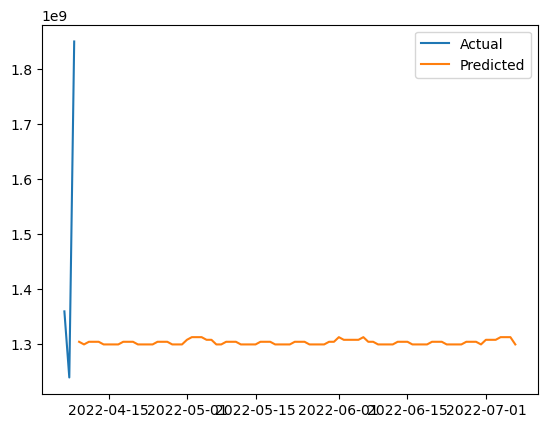

In [30]:
plt.plot(df.index, df[target], label='Actual')
plt.plot(future_dates, predictions, label='Predicted')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# TRAIN
train_pred = model.predict(X_train)

print("TRAIN MAE:", mean_absolute_error(y_train, train_pred))
print("TRAIN RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("TRAIN R2:", r2_score(y_train, train_pred))


# TEST
test_pred = model.predict(X_test)

print("TEST MAE:", mean_absolute_error(y_test, test_pred))
print("TEST RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("TEST R2:", r2_score(y_test, test_pred))

TRAIN MAE: 28800000.0
TRAIN RMSE: 28899826.98910151
TRAIN R2: 0.768
TEST MAE: 550000000.0
TEST RMSE: 550000000.0
TEST R2: nan


e:\app\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
